In [ ]:
pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   --------- ------------------------------ 2.4/9.6 MB 11.2 MB/s eta 0:00:01
   ---------------------- ----------------- 5.5/9.6 MB 14.0 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.6 MB 12.3 MB/s eta 0:00:01
   ---------------------------------- ----- 8.4/9.6 MB 10.8 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 9.5 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodel

# NYC Yellow Cab - Statiscal and Hypothesis Testing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [79]:
# create training dataframe
path = r"E:\Master Degree\1st Semester 2025\DSE 501\Project1\yellow_tripdata_2024-01_cleaned.csv"
df = pd.read_csv(path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2828075 entries, 0 to 2828074
Data columns (total 32 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        float64
 4   trip_distance          float64
 5   RatecodeID             float64
 6   store_and_fwd_flag     object 
 7   PULocationID           int64  
 8   DOLocationID           int64  
 9   payment_type           int64  
 10  fare_amount            float64
 11  extra                  float64
 12  mta_tax                float64
 13  tip_amount             float64
 14  tolls_amount           float64
 15  improvement_surcharge  float64
 16  total_amount           float64
 17  congestion_surcharge   float64
 18  Airport_fee            float64
 19  trip_duration_minutes  float64
 20  pickup_date            object 
 21  pickup_hour            int64  
 22  pickup_day_of_week

## 1. Temporal Demand and Pricing

### 1 Compare fare amounts during peak time

In [44]:
df['is_peak_hour'].unique() # 6 PM (18.00-18.59)

array([0, 1])

In [63]:
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

In [64]:
# check distribution of total fare - refer to EDA the total fare is right-skewed
# choose the model time and fare = continuous variables and the fare is skewed so the suitable model to analysis
# for this hypothesis is log-linear regression
# controling with trip distance and duration
distance = df['trip_distance']

df['trip_duration_min'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60 # Trip duration in minutes

In [47]:
df = df[df['fare_amount'] > 0] 
df.shape 

(2827781, 33)

In [48]:
y_log = np.log(df['fare_amount'])
X_log = sm.add_constant(df[['is_peak_hour', 'trip_distance', 'trip_duration_min']])
 
log_model = sm.OLS(y_log, X_log).fit()
print(log_model.summary())

                            OLS Regression Results                            
Dep. Variable:            fare_amount   R-squared:                       0.802
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                 3.818e+06
Date:                Mon, 08 Dec 2025   Prob (F-statistic):               0.00
Time:                        00:29:07   Log-Likelihood:            -5.8325e+05
No. Observations:             2827781   AIC:                         1.167e+06
Df Residuals:                 2827777   BIC:                         1.167e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 2.0065      0.00

### 2 Compare fare amounts during rush hour period

In [60]:
df["rush_hour"] = np.where((df["pickup_hour"] >= 16) & (df["pickup_hour"] <= 20), 1, 0)

In [65]:
df = df[df['fare_amount'] > 0] 
df.shape 

(2827781, 34)

In [66]:
y_log = np.log(df['fare_amount'])
X_log = sm.add_constant(df[['rush_hour', 'trip_distance', 'trip_duration_min']])

log_model = sm.OLS(y_log, X_log).fit()
print(log_model.summary())

                            OLS Regression Results                            
Dep. Variable:            fare_amount   R-squared:                       0.802
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                 3.819e+06
Date:                Mon, 08 Dec 2025   Prob (F-statistic):               0.00
Time:                        00:41:35   Log-Likelihood:            -5.8270e+05
No. Observations:             2827781   AIC:                         1.165e+06
Df Residuals:                 2827777   BIC:                         1.165e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 2.0118      0.00

## 2. Trip Distance and Fare Elasticity

### 1 Compare trip distance and new total amount

In [ ]:
#create new total amount
df["new_total_amount"] = df["total_amount"] - df["tip_amount"] - df["Airport_fee"] - df["mta_tax"]

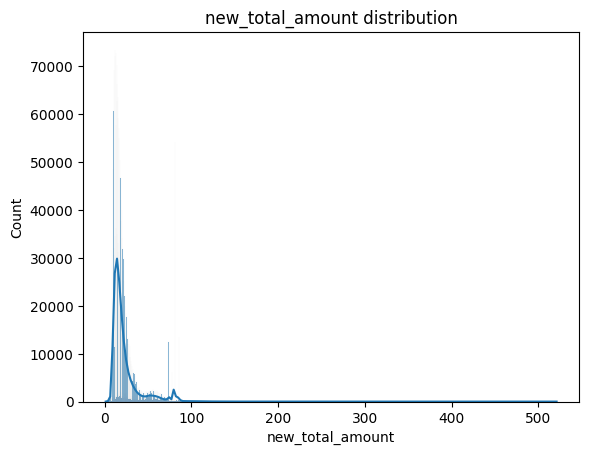

In [ ]:
# check new total amount skew or not
sns.histplot(df["new_total_amount"], kde=True)
plt.title("new_total_amount distribution")
plt.show()

In [ ]:
df21 = df[df['new_total_amount'] > 0]
df21.shape

(2827956, 33)

In [127]:
df21["distance_sq"] = df21["trip_distance"] ** 2
y_log = np.log(df21["new_total_amount"])
X_log = sm.add_constant(df21[['trip_distance', 'distance_sq']])
log_model = sm.OLS(y_log, X_log).fit()
print(log_model.summary())

                            OLS Regression Results                            
Dep. Variable:       new_total_amount   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.825
Method:                 Least Squares   F-statistic:                 6.665e+06
Date:                Fri, 05 Dec 2025   Prob (F-statistic):               0.00
Time:                        16:58:48   Log-Likelihood:                 93389.
No. Observations:             2827956   AIC:                        -1.868e+05
Df Residuals:                 2827953   BIC:                        -1.867e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             2.4743      0.000   1.19e+04

### 2. Compare congestion pricing and new fare amount

In [131]:
df["new_fare_amount"] = df["fare_amount"] + df["congestion_surcharge"]
df22 = df[df['new_fare_amount'] > 0]
df22.shape

(2827801, 33)

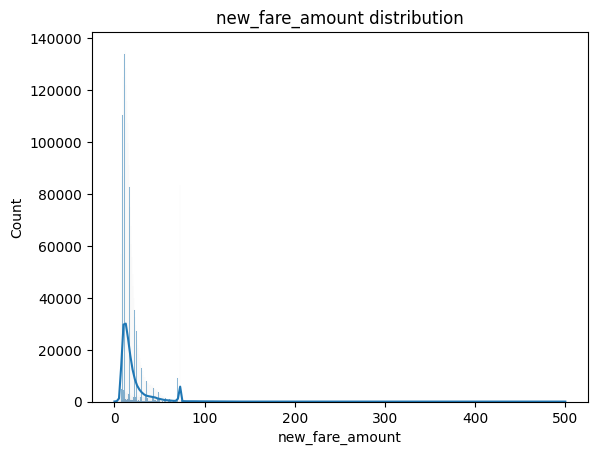

In [134]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df22["new_fare_amount"], kde=True)
plt.title("new_fare_amount distribution")
plt.show()

In [138]:
# Make independent copy
df22 = df22.copy()

# List of CRZ zone IDs
congestion_zone_ids = [
    4,12,13,24,41,42,43,45,48,50,68,74,75,
    79,87,88,90,100,103,104,105,107,113,114,
    116,119,120,125,127,128,137,140,141,142,
    143,144,148,152,153,158,161,162,163,164
]

# Trips inside congestion relief zone
df22["in_congestion_zone"] = (
    df22["PULocationID"].isin(congestion_zone_ids) |
    df22["DOLocationID"].isin(congestion_zone_ids)
).astype(int)

# Trips that were charged congestion surcharge
df22["paid_congestion_fee"] = (df22["congestion_surcharge"] > 0).astype(int)

# Final congestion indicator
df22["congestion"] = (
    df22["in_congestion_zone"] | df22["paid_congestion_fee"]
).astype(int)


In [139]:
df22["distance_sq"] = df22["trip_distance"] ** 2
y_log = np.log(df22["new_fare_amount"])
X_log = sm.add_constant(df22[['trip_distance', 'congestion', 'distance_sq']])
log_model = sm.OLS(y_log, X_log).fit()
print(log_model.summary())

                            OLS Regression Results                            
Dep. Variable:        new_fare_amount   R-squared:                       0.799
Model:                            OLS   Adj. R-squared:                  0.799
Method:                 Least Squares   F-statistic:                 3.740e+06
Date:                Fri, 05 Dec 2025   Prob (F-statistic):               0.00
Time:                        17:48:22   Log-Likelihood:            -2.1606e+05
No. Observations:             2827801   AIC:                         4.321e+05
Df Residuals:                 2827797   BIC:                         4.322e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             2.2286      0.001   3072.665

## Customer Satisfaction and Tip Behavior 

In [155]:
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

In [156]:
df['trip_duration_min'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60 # Trip duration in minutes

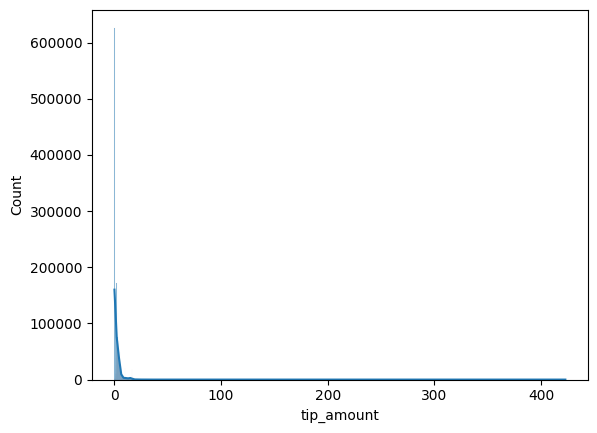

In [157]:
sns.histplot(df["tip_amount"], kde=True)
plt.show()


In [166]:
df["tip_percent"] = (df["tip_amount"] / df["fare_amount"]) * 100
df3 = df[(df["fare_amount"] > 0) & (df["tip_percent"] >= 0)]
df3.shape

(2827781, 34)

In [ ]:
y = df3["tip_percent"]
X = sm.add_constant(df3[['trip_distance', 'trip_duration_min']])
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            tip_percent   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     239.4
Date:                Fri, 05 Dec 2025   Prob (F-statistic):          1.04e-104
Time:                        21:39:47   Log-Likelihood:            -1.9494e+07
No. Observations:             2827781   AIC:                         3.899e+07
Df Residuals:                 2827778   BIC:                         3.899e+07
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                24.8951      0.23

To determine whether lower tips are caused by heavy traffic or delays, we conducted three hypothesis tests.

### 1 Compare Rush hour Traffic (4-8 PM)
### 2 Compare Peak hour (6 PM only)

In [69]:
# 2. Data preparation --------------------------------------------------

# Make sure pickup and drop-off are datetime
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

# Trip duration in minutes
df["trip_duration_min"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

# Tip percentage: tip / fare_amount * 100 (adjust if you used total_amount instead)
df["tip_percent"] = (df["tip_amount"] / df["fare_amount"]) * 100

# Filter: positive fare, positive tip, positive duration & distance
df = df[
    (df["fare_amount"] > 0)
    & (df["tip_amount"] > 0)
    & (df["trip_distance"] > 0)
    & (df["trip_duration_min"] > 0)
].copy()

# Average speed (miles per hour)
df["avg_speed_mph"] = df["trip_distance"] / (df["trip_duration_min"] / 60)

# Peak-hour flag (example: 4pm–8pm) – adjust if needed
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
df["rush_hour"] = np.where((df["pickup_hour"] >= 16) & (df["pickup_hour"] <= 20), 1, 0)

# 3. Models ------------------------------------------------------------

# Model 1: Rush hour, Duration, Distanc → Tip %
model2 = smf.ols(
    formula="tip_percent ~  rush_hour + trip_duration_min + trip_distance",
    data=df
).fit()
print("\n=== Model 1: tip_percent ~  rush_hour + trip_duration_min + trip_distance ===")
print(model2.summary())

# Model 2: Peak hour, Duration, Distance → Tip %
# "Do peak hours and delays relate to lower tips?"
model3 = smf.ols(
    formula="tip_percent ~ is_peak_hour + trip_duration_min + trip_distance",
    data=df
).fit()
print("\n=== Model 2: tip_percent ~ peak_hour + trip_duration_min + trip_distance ===")
print(model3.summary())



=== Model 1: tip_percent ~  rush_hour + trip_duration_min + trip_distance ===
                            OLS Regression Results                            
Dep. Variable:            tip_percent   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     118.8
Date:                Mon, 08 Dec 2025   Prob (F-statistic):           5.89e-77
Time:                        01:13:14   Log-Likelihood:            -1.5481e+07
No. Observations:             2206316   AIC:                         3.096e+07
Df Residuals:                 2206312   BIC:                         3.096e+07
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------

### 3. Compare Congestion Zone Trips

In [170]:
df3 = df3.copy()

In [171]:
#sub hypothesis
congestion_zone_ids = [
    4,12,13,24,41,42,43,45,48,50,68,74,75,
    79,87,88,90,100,103,104,105,107,113,114,
    116,119,120,125,127,128,137,140,141,142,
    143,144,148,152,153,158,161,162,163,164
]

# Trips inside congestion relief zone
df3["in_congestion_zone"] = (
    df3["PULocationID"].isin(congestion_zone_ids) |
    df3["DOLocationID"].isin(congestion_zone_ids)
).astype(int)

# Trips that were charged congestion surcharge
df3["paid_congestion_fee"] = (df3["congestion_surcharge"] > 0).astype(int)

# Final congestion indicator
df3["congestion"] = (
    df3["in_congestion_zone"] | df3["paid_congestion_fee"]
).astype(int)

y = df3["tip_percent"]
X = sm.add_constant(df3[['trip_distance', 'trip_duration_min','congestion']])
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            tip_percent   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     214.4
Date:                Fri, 05 Dec 2025   Prob (F-statistic):          4.48e-139
Time:                        22:23:49   Log-Likelihood:            -1.9493e+07
No. Observations:             2827781   AIC:                         3.899e+07
Df Residuals:                 2827777   BIC:                         3.899e+07
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                17.0341      0.65

## 5 Payment Method and Customer Preferences

In [80]:
# 1. Define holidays
january_holidays_2024 = [
    "2024-01-01",
    "2024-01-15"
]
january_holidays_2024 = pd.to_datetime(january_holidays_2024)

# 2. Convert datetime
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])

# 3. Extract date
df["pickup_date"] = df["tpep_pickup_datetime"].dt.date

# 4. Holiday indicator
df["is_holiday"] = df["pickup_date"].isin(january_holidays_2024.date).astype(int)

# 5. Weekend indicator (Saturday=5, Sunday=6)
df["is_weekend"] = df["tpep_pickup_datetime"].dt.weekday.isin([5, 6]).astype(int)

# 6. Combined indicator (optional)
df["holiday_or_weekend"] = ((df["is_holiday"] == 1) | (df["is_weekend"] == 1)).astype(int)


In [81]:
df["is_flexfare"] = df["payment_type"].isin([0]).astype(int)
df["is_cash"]  = (df["payment_type"] == 2).astype(int)
df["is_credit"]  = (df["payment_type"] == 1).astype(int)
df["is_dispute"] = df["payment_type"].isin([4]).astype(int)
df["is_other"]    = (~df["payment_type"].isin([0,1,2,4])).astype(int)
df["time_period"] = df["holiday_or_weekend"].replace({0: "Weekday", 1: "Weekend"})


In [82]:
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

def chi_square_summary(ct, name):
    chi2, p, dof, expected = chi2_contingency(ct)
    n = ct.values.sum()
    phi2 = chi2 / n
    r, k = ct.shape
    cramers_v = np.sqrt(phi2 / min(k - 1, r - 1))
    
    return {
        "Payment Method": name,
        "Chi-square": chi2,
        "p-value": p,
        "df": dof,
        "Cramér's V": cramers_v,
        "Total N": n
    }

# Build contingency tables
ct_flex    = pd.crosstab(df["time_period"], df["is_flexfare"])
ct_cash    = pd.crosstab(df["time_period"], df["is_cash"])
ct_credit  = pd.crosstab(df["time_period"], df["is_credit"])
ct_dispute = pd.crosstab(df["time_period"], df["is_dispute"])
ct_other = pd.crosstab(df["time_period"], df["is_other"])

# Run chi-square for each payment method
results = [
    chi_square_summary(ct_flex,    "Flex Fare"),
    chi_square_summary(ct_cash,    "Cash"),
    chi_square_summary(ct_credit,  "Credit Card"),
    chi_square_summary(ct_dispute, "Dispute"),
    chi_square_summary(ct_dispute, "Other"),
]

# Put in a DataFrame for a nice table
chi_summary_df = pd.DataFrame(results)
print(chi_summary_df)


  Payment Method   Chi-square        p-value  df  Cramér's V  Total N
0      Flex Fare  6986.561500   0.000000e+00   1    0.049703  2828075
1           Cash   381.382474   6.222665e-85   1    0.011613  2828075
2    Credit Card   848.897328  1.262670e-186   1    0.017325  2828075
3        Dispute    22.997087   1.622470e-06   1    0.002852  2828075
4          Other    22.997087   1.622470e-06   1    0.002852  2828075


## Geographic Fare Variation

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm

# -----------------------------
# 1. DEFINE AIRPORT ZONE IDs
# -----------------------------
airport_ids = [132, 138]   # JFK=132, LaGuardia=138
# If you want to include Newark airport: airport_ids.append(1)

# -----------------------------
# 2. CREATE AIRPORT INDICATOR
# -----------------------------
df["is_airport"] = (
    df["PULocationID"].isin(airport_ids) |
    df["DOLocationID"].isin(airport_ids)
).astype(int)

# -----------------------------
# 3. SPLIT INTO AIRPORT vs CITY TRIPS
# -----------------------------
df_airport = df[df["is_airport"] == 1].copy()
df_city = df[df["is_airport"] == 0].copy()

# -----------------------------
# 4. PREPARE DATA FOR REGRESSION
# -----------------------------
# Only keep trips with valid fare amounts
df_city = df_city[df_city["fare_amount"] > 0]

# Log-transform fare for normality
df_city["log_fare"] = np.log(df_city["fare_amount"])

# -----------------------------
# 5. RUN REGRESSION FOR H6 (CITY TRIPS)
# -----------------------------
# y = df_city["log_fare"]
# X = sm.add_constant(df_city[['trip_distance', 'trip_duration_min','PULocationID','DOLocationID']])
# model = sm.OLS(y, X).fit()
# print(model.summary())

top_pu = df_city["PULocationID"].value_counts().index[:50]
top_do = df_city["DOLocationID"].value_counts().index[:50]

df_sub = df_city[
    df_city["PULocationID"].isin(top_pu) &
    df_city["DOLocationID"].isin(top_do)
]


model = smf.ols(
    "log_fare ~ trip_distance + trip_duration_min + C(PULocationID) + C(DOLocationID)",
    data=df_sub
).fit()


In [25]:
df_city["PU_DO_pair"].shape

(2558423,)

In [26]:
# 1. Create pair id
df_city["PU_DO_pair"] = (
    df_city["PULocationID"].astype(str) + "_" + df_city["DOLocationID"].astype(str)
)

# 2. Keep only the most frequent 200 pairs (for example)
pair_counts = df_city["PU_DO_pair"].value_counts()
common_pairs = pair_counts.head(1000).index

df_pairs = df_city[df_city["PU_DO_pair"].isin(common_pairs)].copy()

# 3. Randomly sample, e.g. 100,000 rows to keep memory small
df_pairs_sample = df_pairs.sample(n=200_000, random_state=42)

# 4. Run pair fixed-effects model on this *small* sample
model_pairs = smf.ols(
    "log_fare ~ trip_distance + trip_duration_min + C(PU_DO_pair)",
    data=df_pairs_sample
).fit()

print(model_pairs.summary())

# ANOVA for pair effect
anova_pairs = sm.stats.anova_lm(model_pairs, typ=2)
print(anova_pairs.loc["C(PU_DO_pair)"])



                            OLS Regression Results                            
Dep. Variable:               log_fare   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.848
Method:                 Least Squares   F-statistic:                     1117.
Date:                Sat, 06 Dec 2025   Prob (F-statistic):               0.00
Time:                        08:45:35   Log-Likelihood:                 77145.
No. Observations:              200000   AIC:                        -1.523e+05
Df Residuals:                  198998   BIC:                        -1.421e+05
Df Model:                        1001                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               